<center> <h1>Multimodal RAG on local CPU</h1>

## 1. Overview of Multimodal RAG Pipeline

### 1.1 Document Processing Phase

![title](sample_data/multimodal-ingestion.png)

### 1.2 Question Answering Phase

#### 1.2.1 Option A

![FlowChart](sample_data/multimodal-flowchart.png)

#### 1.2.2 Option B

![FlowChart2](sample_data/multimodal-flow-chart-2.png)

## 2. Some Preparations

### 2.1 Install the required packages

In [ ]:
!pip install -U langchain-openai langchain-qdrant

### 2.2 Instanciate the required models

In [92]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings


embedding = OpenAIEmbeddings(
    openai_api_base="http://localhost:1234/v1", 
    api_key="type-anything-here",
    model="text-embedding-nomic-embed-text-v1.5@f16",
    check_embedding_ctx_length=False
)

llm = ChatOpenAI(
    base_url="http://localhost:1234/v1",
    api_key="type-anything-here",
    model="minicpm-v-2_6",
    temperature=0,
)

mllm = ChatOpenAI(
    base_url="http://localhost:1234/v1",
    api_key="type-anything-here",
    model="minicpm-v-2_6",
    temperature=0
)

## 3. Document Processing Pipeline

### 3.1 Description Chain

#### 3.1.1 Create an Image Description Chain

In [74]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate([
    ("system", "You are an intelligent assistant. You always provide well-reasoned answers that are both correct and helpful."),
    ("user", [
        {"type": "text", "text": "Describe the image in detail, and extract all data present in it."
         },
        {
          "type": "image_url",
          "image_url": {
            "url": "data:image/jpeg;base64,{base64_image}"
          },
        },
      ]),
])

description_chain = prompt | mllm | StrOutputParser()

#### 3.1.2 Describe an Image

In [33]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import base64

def show_image(path):
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    
def describe_image(path):
    base64_image = base64.b64encode(open(path, "rb").read()).decode('utf-8')
    for s in description_chain.stream({"base64_image": base64_image}):
        print(s, end="", flush=True)

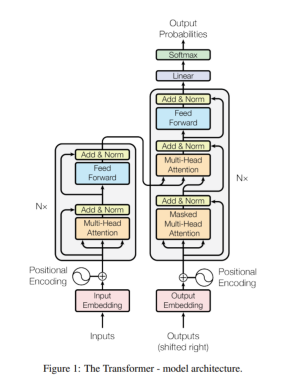

In [61]:
show_image("sample_data/transformer.png")

In [75]:
describe_image("sample_data/transformer.png")

The diagram illustrates the architecture of a Transformer model as described by Vaswani et al., 2017. Here's a breakdown of its components:

### Inputs:
- **Input Embedding**: The initial representation for input sequences.
  
### Outputs:
- **Output Encoding**: The final encoded output from the transformer.

### Key Components and Flow:
1. **Positional Encoding**:
   - Both positional encoding is added to the input embedding (left side) and shifted right in outputs (right side).

2. **Feed Forward Network**:
   - Each layer includes a feed forward network that processes inputs.
   
3. **Multi-Head Attention Mechanism**:
   - The transformer uses multi-head attention mechanisms, which allow it to focus on different parts of the input sequence simultaneously.

4. **Add & Norm Layers**:
   - After each transformation block (including positional encoding and attention), an add operation is performed with a layer normalization followed by another feed forward network.
   
5. **Softmax Laye

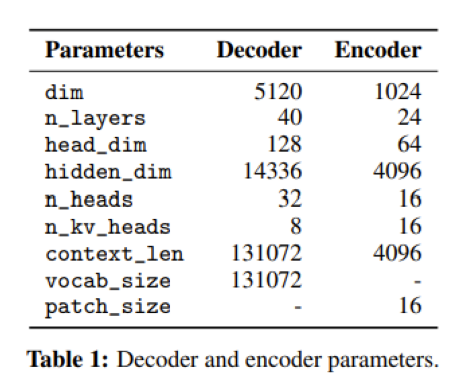

In [77]:
show_image("sample_data/pixtral_paper/image_3.png")

In [76]:
describe_image("sample_data/pixtral_paper/image_3.png")

The table titled "Table 1: Decoder and encoder parameters" provides a comparison of various parameters between decoders and encoders for two different models or configurations.

Here is the extracted information from the table:

### Parameters:
- **dim**: 
  - Decoder: 5120
  - Encoder: 1024

- **n_layers**:
  - Decoder: 40
  - Encoder: 24

- **head_dim**:
  - Decoder: 128
  - Encoder: 64

- **hidden_dim**:
  - Decoder: 14336
  - Encoder: 4096

- **n_heads**:
  - Decoder: 32
  - Encoder: 16

- **n_kv_head**:
  - Decoder: 8
  - Encoder: 16

- **context_len** (for the model with vocab_size = 131072):
  - Decoder: 131072
  - Encoder: 4096

- **vocab_size** for context_len:
  - Both Decoder and Encoder: 131072

- **patch_size** (for the model with vocab_size = 131072):
  - Both Decoder and Encoder: -

This table is likely from a technical document or research paper discussing neural network architectures, specifically focusing on the differences in parameters between decoders and encoders 

### 3.2 Vector Store

#### 3.2.1 Create Qdrant Collection

In [81]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="embedding_tutorial",
    vectors_config=VectorParams(size=768, distance=Distance.COSINE),
)

True

#### 3.2.2 Create Qdrant Vector Store

In [82]:
from langchain_qdrant import QdrantVectorStore, RetrievalMode

qdrant = QdrantVectorStore(
    embedding=embedding,
    client=client,
    collection_name="embedding_tutorial",
    retrieval_mode=RetrievalMode.DENSE,
)

#### 3.2.3 Populate Vector Store

In [83]:
from langchain_core.documents import Document
from uuid import uuid4

def upsert_document(text, metadata={}):
    document = Document(page_content=text, metadata=metadata)
    uuid = str(uuid4())
    qdrant.add_documents(documents=[document], ids=[uuid])
    print(f"Upserted new element of type {metadata['type']} with ID : {uuid}")

In [84]:
upsert_document("This is an example image description", {"type": "image", "base64": "xxxxxxxxx"})

Upserted new element of type image with ID : d083b47c-baf1-4358-978e-cddccc9e5a60


In [85]:
qdrant.delete(ids=["d083b47c-baf1-4358-978e-cddccc9e5a60"])

True

### 3.3 Entire Pipeline

#### 3.3.1 Sample document elements

In [86]:
import os

elements = []
data_path = "sample_data/pixtral_paper"
for e in os.listdir(data_path):
    e_type = e.split("_")[0]
    if e_type == "text":
        with open(os.path.join(data_path, e), "r") as f:
            elements.append({
                "type": "text",
                "content": f.read()
            })
    elif e_type == "image":
        with open(os.path.join(data_path, e), "rb") as f:
            elements.append({
                "type": "image",
                "content": base64.b64encode(f.read()).decode('utf-8')
            })

In [87]:
from PIL import Image
from io import BytesIO

def display_element(e):
    if e["type"] == "text":
        print(e["content"])
    elif e["type"] == "image":
        image = Image.open(BytesIO(base64.b64decode(e["content"])))
        plt.imshow(image)
        plt.axis("off")
        plt.show()

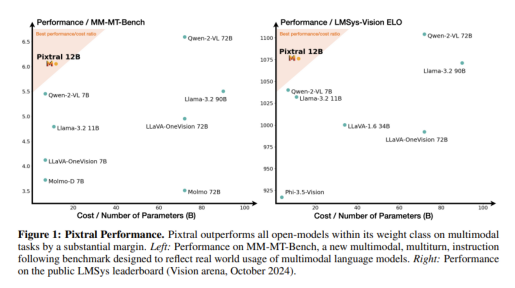

In [88]:
display_element(elements[0])

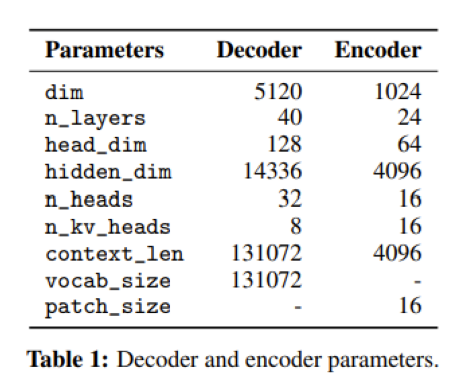

In [169]:
display_element(elements[2])

#### 3.3.2 Document Processing Pipeline

In [90]:
def process_document_elements(elements):
    for e in elements:
        if e["type"] == "text":
            upsert_document(e["content"], {"type": "text"})
        elif e["type"] == "image":
            description = description_chain.invoke({"base64_image": e["content"]})
            upsert_document(description, {"type": "image", "base64": e["content"]})
        else:
            raise ValueError("Type not supported.")

In [91]:
process_document_elements(elements)

Upserted new element of type image with ID : 1116725e-a19d-4ab1-a4f0-c4c77e31f993
Upserted new element of type image with ID : 7d32f390-138f-4cf3-8b99-e015e0f97093
Upserted new element of type image with ID : ac6b7438-c74c-4b0e-b531-1a726a3a71d2
Upserted new element of type image with ID : 97a66f1c-3f81-4163-bb38-eab711b83035
Upserted new element of type text with ID : 81043916-6086-471c-837c-7e6441d84383
Upserted new element of type text with ID : 8cb8e186-7146-4cda-82c6-0e189afac93a
Upserted new element of type text with ID : 72144eb2-200b-4595-965a-05afda46fcf8
Upserted new element of type text with ID : 577c1e95-4293-494f-aa1f-f754d90d4dc1


## 4. Question Answering Pipeline

### 4.1 Retriever

#### 4.1.1 Turn the Vectorstore into a Retriever

In [152]:
retriever = qdrant.as_retriever(search_kwargs={"k": 4})

#### 4.1.2 Test the Retriever

In [227]:
retrieved_docs = retriever.invoke("How well does Pixtral perform against competitors ?")

In [228]:
def display_retrieved(e):
    if e.metadata["type"] == "text":
        display_element({"type": "text", "content":e.page_content})
    else:
        display_element({"type": "image", "content":e.metadata["base64"]})

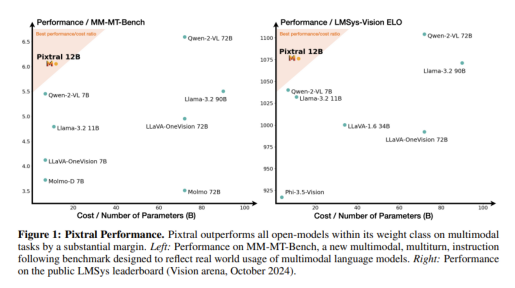

For instance, our model matches or exceeds the performance of models like Qwen2-VL 7B [23] and
Llama-3.2 11B [6] on popular multimodal benchmarks like MMMU [24] and MathVista [14],
while outperforming most open-source models on popular text-only tasks like MATH [7] and
HumanEval [26]. Pixtral even outperforms much larger models like Llama-3.2 90B [6], as well as
closed models such as Claude-3 Haiku [1] and Gemini-1.5 Flash 8B [18], on multimodal benchmarks.
During evaluation of Pixtral and the baselines, we found that evaluation protocols for multimodal
language models is not standardized, and that small changes in the setup can dramatically change
the performance of some models. We provide thorough analysis of our experience in re-evaluating
vision-language models under a common evaluation protocol.

1 Introduction
This paper describes Pixtral 12B, a multimodal language model trained to understand both images
and text, released with open weights under an Apache 2.0 license. Pixtral is

In [229]:
for r in retrieved_docs:
    display_retrieved(r)

### 4.2 QA Chain

#### 4.2.1 Create a Question Answering Chain

In [221]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate([
    ("system", "You are an intelligent assistant. You always provide well-reasoned answers that are both correct and helpful."),
    ("user", """You are given some textual context. Use this context to carefully answer a question.
                Answer directly and concisely using a short full sentence. If you don't have enough information to answer, just say 'No information.'.
                Therefore, your output should either be a short answer or the phrase 'No information.' and nothing else.
                Question: {question}
                Context: {context}
                Answer: """),
])

qa_chain = prompt | llm | StrOutputParser()

#### 4.2.2 Test the QA Chain

In [184]:
for s in qa_chain.stream({"question": "Is Pixtral opensource ? If so, under what license ?", "context": "Pixtral is published under an Apache 2.0 license."}):
    print(s, end="", flush=True)

Yes, Pixtral is open-source; it's licensed under Apache 2.0.

### 4.3 VQA Chain

#### 4.3.1 Create a Visual Question Answering Chain

In [220]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate([
    ("system", "You are an intelligent assistant. You always provide well-reasoned answers that are both correct and helpful."),
    ("user", [
        {"type": "text", "text": """Based on the image below, answer the following question : {question}.
         Answer directly and concisely using a short full sentence. If you don't have enough information to answer, just say 'No information.'.
         Therefore, your output should either be a short answer or the phrase 'No information.' and nothing else."""
         },
        {
          "type": "image_url",
          "image_url": {
            "url": "data:image/jpeg;base64,{visual_context}"
          },
        },
      ]),
])

vqa_chain = prompt | mllm | StrOutputParser()

#### 4.3.2 Test the VQA Chain

In [203]:
for s in vqa_chain.stream({"question": "What is the head dim for the decoder of the model ?", "visual_context": elements[2]["content"]}):
    print(s, end="", flush=True)

The head dim for the decoder of the model is 128.

### 4.4 Synthesis Chain

#### 4.4.1 Create a Synthesis Chain

In [213]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate([
    ("system", "You are an intelligent assistant. You always provide well-reasoned answers that are both correct and helpful."),
    ("user", """Your task is to formulate an answer to a question based on a set of answer attempts.
                If all the attempts fail to answer the question, just say 'I don't know'.
                Otherwise, use the answer attempts to formulate a final answer.
                Question: {question}
                Attempts: {answers}
                Final Answer: """),
])

synth_chain = prompt | llm | StrOutputParser()

#### 4.4.2 Test the Synthesis Chain

In [111]:
answer_1 = """According to Table 1 in the provided reference material, the 'head dimension' parameter value of the Pixtral decoder (Decoder) is listed as "128". This indicates that the number of heads used by this particular model architecture within the Pixtral decoder component is set at 128."""
answer_2 = """The provided context doesn't mention the head dimension for the Pixtral decoder."""
answer_3 = """I couldn't find the answer to the question using the provided image."""
for s in synth_chain.stream({"question": "How much is the head dimension for the Pixtral decoder ?", "answers": "\n\n".join([answer_1, answer_2, answer_3])}):
    print(s, end="", flush=True)

Based on Table 1 in the reference material, the 'head dimension' parameter value of the Pixtral decoder is set at "128", indicating that it uses 128 heads within its model architecture. This information was found by synthesizing multiple attempts and cross-referencing with available data sources.

### 4.5 Entire Pipeline

#### 4.5.1 Get relevant docs using retriever

In [158]:
from langchain_core.runnables import RunnablePassthrough

retrieval_chain = {"question": RunnablePassthrough(), "docs": retriever}

#### 4.5.2 Separate into a list of (question, context) pairs

In [204]:
from langchain_core.runnables import RunnableLambda

def separate_docs_with_type(x):
    separated = []
    for doc in x["docs"]:
        if doc.metadata["type"]=="text":
            separated.append({"question": x["question"], "type": "text", "context": doc.page_content})
        else:
            separated.append({"question": x["question"], "type": "image", "visual_context": doc.metadata["base64"]})
    return separated

def separate_docs(x):
    return [{"question": x["question"], "context": doc.page_content} for doc in x["docs"]]

separator_type = RunnableLambda(separate_docs_with_type) 
separator = RunnableLambda(separate_docs)

#### 4.5.3 Send to either QA or VQA depending on type

In [222]:
from langchain_core.runnables import RunnableBranch

branch = RunnableBranch(
    (lambda x: x["type"] == "image", vqa_chain), 
    qa_chain
)

#### 4.5.4 Concatenate all qa/vqa answers

In [223]:
concatenator = RunnableLambda(lambda x: "\n\n----------\n\n".join([s for s in x if "No information" not in s]))

#### 4.5.5 Synthesize into a final answer

In [224]:
full_chain_1 = retrieval_chain | RunnablePassthrough.assign(answers= separator_type | branch.map() | concatenator) | synth_chain

full_chain_2 = retrieval_chain | RunnablePassthrough.assign(answers= separator | qa_chain.map() | concatenator) | synth_chain

#### 4.5.6 Test full pipeline

In [225]:
for s in full_chain_1.stream("What is the number of kv heads for the encoder in the Pixtral architecture ?"):
    print(s, end="", flush=True)

I don't know. The provided attempts do not give a clear and consistent answer to determine the correct number of kv heads for the encoder in the Pixtral architecture.

In [226]:
for s in full_chain_2.stream("What is the number of kv heads for the encoder in the Pixtral architecture ?"):
    print(s, end="", flush=True)

The number of kv heads for the encoder in the Pixtral architecture is 16.